# mREIT Carry — a quantitative teardown 🔬
### Total-return vs price-only carry decomposition (HAC *t*) · NW-HAC alpha vs a duration-matched levered-IEF benchmark · lag & subperiod robustness · crisis autopsies · a synthetic faithful-engine control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — *"mREITs pay 10-14% of real leveraged-MBS carry"* — is unusual for this desk in that its central number is **true**; the study's job is to measure what the carry costs and what it loses to its own passive benchmark.

> ⚠️ **Data + survivorship note.** Double yfinance tape (auto-adjusted total-return AND raw split-adjusted price-only) for REM / NLY / AGNC / IEF / SPY / BIL, REM window 2007-06-30 → 2026-06-30 (229 months, GFC included), as-of 2026-06-30. **REM is an index fund — the headline leg is not survivor-biased**; NLY/AGNC are the two biggest survivors, quoted as colour. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `3b2ec2fc7dd3`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mreit_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    TR, PX = data.load_real()
    MTR, MPX = st.aligned_monthly(TR, PX, ["REM", "IEF", "SPY", "BIL"])
else:
    TR = PX = MTR = MPX = None
print("real mREIT cache present:", HAVE_REAL,
      "| months:", (0 if MTR is None else len(MTR)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-06-30', 'end': '2026-06-30', 'n_months': 229, 'years': 19.1, 'as_of': '2026-06-30', 'fingerprint': '3b2ec2fc7dd3', 'decomp': {'REM': (229, 84.69, 10.65, 18.09, -1.13, -10.96, 80.5, 10.9), 'NLY': (229, 103.04, 13.09, 23.01, 7.52, -5.18, 399.0, 36.2), 'AGNC': (217, 121.46, 15.59, 17.8, 11.8, -3.22, 751.4, 55.3)}, 'perf': {'REM': (-1.13, 24.17, 0.04, -67.44), 'IEF': (3.32, 6.7, 0.32, -23.15), 'SPY': (10.68, 15.58, 0.64, -50.78), 'BIL': (1.36, 0.56, None, -0.42)}, 'rem_excess_bps': 7.78, 'rem_excess_t': 0.18, 'race': {'REM': (-87.62, -10.02, -2.5, 0.42, 1.91, 1.05, 6.8, 0.46, -1.13, 12.07, -67.4, -49.7, -3.01), 'NLY': (-8.11, -0.97, -0.22, 1.05, 4.06, 0.78, 4.34, 0.31, 7.52, 11.03, -45.8, -33.4, -0.27), 'AGNC': (18.83, 2.28, 0.43, 1.2, 4.41, 0.82, 5.03, 0.32, 11.8, 12.03, -48.1, -36.0, 0.51)}, 'robust_lags': [(3, -87.62, -2.32), (6, -87.62, -2.5), (12, -87.62, -2.78)], 'exgfc': {'alpha_bps': -76.48, 't': -1.93, 'div_ann': 10.33, 'div_t': 17.0, 'tr_cagr': 4.28, 'px_cagr': -5.78}, 'crises': [('GFC 2007-09', -74.7, -40.9, -31.0, -55.2, -6.2), ('Taper tantrum 2013', -24.8, -34.6, -36.9, -5.6, -9.1), ('COVID 2020', -68.5, -60.1, -51.8, -33.7, -4.7), ('Rate shock 2022', -40.3, -47.8, -48.2, -24.5, -17.4)], 'syn': [(0.0, 0.0, 1.49, 0.71, -6.45, -0.35), (100.0, -70.0, 101.49, 48.21, -76.45, -4.15)]}


real mREIT cache present: True | months: 229


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Dividend component **+84.69 bps/mo (+10.65%/yr)** on REM at **HAC t = +18.09** (NLY t = 23.01, AGNC t = 17.80); the financing erosion is equally real — carry premium **-87.62 bps/mo at HAC t = -2.50**. |
| **Tradability** | `MIRAGE` | TR CAGR **-1.13%/yr** (excess over bills t = +0.18 — cash), maxDD **-67.4%**, and **-10.02%/yr (t = -2.50)** behind the beta-matched levered IEF+SPY benchmark. |
| **Free lunch?** | `BUSTED` | Price-only CAGR **-10.96%/yr** — $100 of capital → **$10.9**. The coupon is NAV liquidation plus crash risk (β_SPY = 1.05). |

> 💡 In plain words: the coupon is real and huge; the vehicle converts it into less than T-bills at equity-crash risk. Real carry, mirage package — the third sibling of [341](../../341-mlp-pipelines/README.md) and [342](../../342-bdc-yield/README.md).

## 1 · The claim, steelmanned

Let $r^{TR}_{t}$ and $r^{PX}_{t}$ be a name's monthly total-return and price-only returns. The **dividend component** (the carry the pitch sells) is

$$c_t = r^{TR}_t - r^{PX}_t \ge 0,$$

and the claim decomposes into:

- **H₁ (the carry exists).** $\bar{c} \approx$ 10-14%/yr, significant under a serial-correlation-robust test.
- **H₂ (the carry is kept).** Total return compounds it: TR CAGR is meaningfully positive and the vehicle beats a passive duration-matched mix — i.e. NW-HAC $\alpha \ge 0$ in $r^{mREIT}_t - r^f_t = \alpha + \beta_{IEF}(r^{IEF}_t - r^f_t) + \beta_{SPY}(r^{SPY}_t - r^f_t) + \varepsilon_t$.
- **H₃ (free lunch).** The income is spendable without consuming capital: price-only CAGR $\approx 0$.

We find **H₁ confirmed** (t = 17.8-23.0), **H₂ rejected** (REM α = -87.6 bps/mo at t = -2.50; TR below bills), **H₃ busted** (price leg -11.0%/yr).

## 2 · So what? — what rides on each answer

An agency mREIT is a levered repo carry book: long MBS duration and (negative) convexity, short overnight liquidity, distributing the levered net interest margin. If H₂ held, the package would deliver a retail-accessible carry premium unavailable in plain ETFs — genuinely interesting. If only H₁ holds, the sector is the mortgage flavour of the desk's packaged-carry family (MLPs, BDCs): a real coupon financed by NAV erosion, with the true factor exposure hiding under the income label. The decisive statistic is the **NW-HAC alpha against the investor's realistic alternative** — levered IEF plus equity beta, financed at bills — not the yield, and not raw CAGR.

## 3 · How we'd know — the protocol

- **Tape.** yfinance daily, downloaded twice (`auto_adjust=True/False`); monthly resample, partial months dropped; REM/NLY window 2007-06-30 → 2026-06-30 (229 months), AGNC from 2008-06 (217). As-of 2026-06-30, fingerprint `3b2ec2fc7dd3`.
- **Carry.** $c_t = r^{TR}_t - r^{PX}_t$; mean tested with Newey-West HAC t (6 lags; 3/12 as robustness) — payout streams are serially correlated.
- **Benchmark.** NW-HAC OLS of excess returns on IEF + SPY excess returns (excess-on-excess, so α is a risk-adjusted spread). Full-sample betas — a risk-decomposition benchmarking choice, stated openly; nothing is a timed rule.
- **Execution/costs.** Passive buy-and-hold decomposition: entry at the first month-end close (the one documented lag — there is no timing signal). Two one-way trades / 19.1 yrs ≈ 0.5 bps/yr; REM's 0.48% ER is inside the tape.
- **Crises.** Fixed documented windows (GFC, taper 2013, COVID, 2022); peak-to-trough TR drawdowns on the daily tape.
- **Positive control.** Synthetic world with planted `carry` and `alpha` knobs; the null (0, 0) must stay silent.

## 4 · The teardown

### 4a · The carry decomposition — H₁

Monthly dividend component per name, with its HAC *t*; against it, the price-only CAGR it rode on.

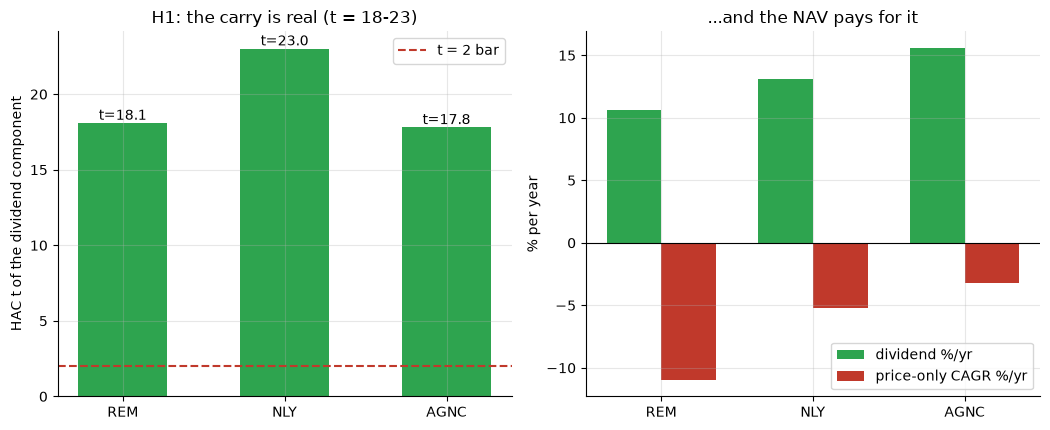

 REM: div +84.69 bps/mo = +10.65%/yr (HAC t +18.09) | TR -1.13%/yr  PX -10.96%/yr  (n=229)
 NLY: div +103.04 bps/mo = +13.09%/yr (HAC t +23.01) | TR +7.52%/yr  PX -5.18%/yr  (n=229)
AGNC: div +121.46 bps/mo = +15.59%/yr (HAC t +17.80) | TR +11.80%/yr  PX -3.22%/yr  (n=217)


In [2]:
names = ['REM', 'NLY', 'AGNC']
if HAVE_REAL:
    rows = []
    for nm in names:
        mtr, mpx = st.aligned_monthly(TR, PX, [nm, 'IEF', 'SPY', 'BIL'])
        dd = st.decompose(mtr, mpx, nm)
        rows.append((nm, dd['div_bps_mo'], dd['div_ann_pct'], dd['div_hac_t'],
                     dd['tr_cagr_pct'], dd['px_cagr_pct'], dd['n_months']))
else:
    rows = [(nm, R['decomp'][nm][1], R['decomp'][nm][2], R['decomp'][nm][3],
             R['decomp'][nm][4], R['decomp'][nm][5], R['decomp'][nm][0]) for nm in names]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.4))
a1.bar(names, [r[3] for r in rows], color=GREEN, width=.55)
a1.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(rows): a1.annotate(f't={r[3]:.1f}', (i, r[3]), ha='center', va='bottom')
a1.set_ylabel('HAC t of the dividend component'); a1.set_title('H1: the carry is real (t = 18-23)')
a1.legend()
a2.bar(np.arange(3) - .18, [r[2] for r in rows], .36, color=GREEN, label='dividend %/yr')
a2.bar(np.arange(3) + .18, [r[5] for r in rows], .36, color=RED, label='price-only CAGR %/yr')
a2.axhline(0, c='k', lw=.8)
a2.set_xticks(np.arange(3)); a2.set_xticklabels(names)
a2.set_ylabel('% per year'); a2.set_title('...and the NAV pays for it'); a2.legend()
plt.tight_layout(); plt.show()
for r in rows:
    print(f'{r[0]:>4}: div {r[1]:+.2f} bps/mo = {r[2]:+.2f}%/yr (HAC t {r[3]:+.2f}) | '
          f'TR {r[4]:+.2f}%/yr  PX {r[5]:+.2f}%/yr  (n={r[6]})')

> 💡 In plain words: the coupon is as real as statistics gets — REM paid **+10.65%/yr** of hard dividend cash at **t = 18.1** — and every name's price leg is negative. The sector fund's price fell **-10.96%/yr**: the machine pays its coupon substantially out of its own NAV.

### 4b · The decisive test — NW-HAC alpha vs the duration-matched benchmark (H₂)

Each name's monthly excess return regressed on IEF and SPY excess returns (NW, 6 lags). The benchmark portfolio (cash + β·factors) is what a DIY investor could hold instead.

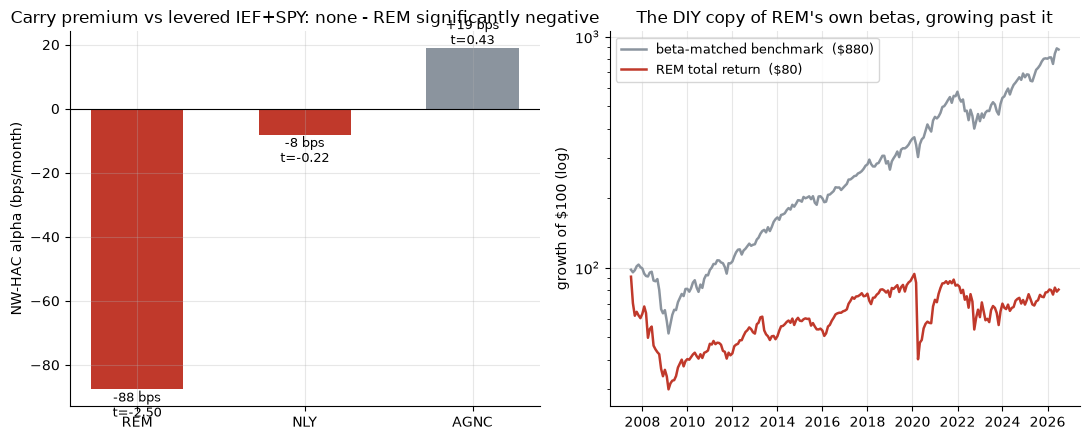

 REM: alpha  -87.62 bps/mo (t -2.50)  b_IEF +0.42  b_SPY +1.05  | CAGR -1.13%/yr vs bench +12.07%/yr
 NLY: alpha   -8.11 bps/mo (t -0.22)  b_IEF +1.05  b_SPY +0.78  | CAGR +7.52%/yr vs bench +11.03%/yr
AGNC: alpha  +18.83 bps/mo (t +0.43)  b_IEF +1.20  b_SPY +0.82  | CAGR +11.80%/yr vs bench +12.03%/yr


In [3]:
names = ['REM', 'NLY', 'AGNC']
if HAVE_REAL:
    rows = []
    for nm in names:
        mtr, _ = st.aligned_monthly(TR, PX, [nm, 'IEF', 'SPY', 'BIL'])
        br = st.benchmark_race(mtr, nm)
        rows.append((nm, br['alpha_bps_mo'], br['t_alpha'], br['beta_IEF'], br['beta_SPY'],
                     br['name_cagr_pct'], br['bench_cagr_pct']))
    mtr_rem, _ = st.aligned_monthly(TR, PX, ['REM', 'IEF', 'SPY', 'BIL'])
    br_rem = st.benchmark_race(mtr_rem, 'REM')
    w_rem = (1 + mtr_rem['REM']).cumprod() * 100
    w_ben = (1 + br_rem['bench_series']).cumprod() * 100
else:
    rows = [(nm, R['race'][nm][0], R['race'][nm][2], R['race'][nm][3], R['race'][nm][5],
             R['race'][nm][8], R['race'][nm][9]) for nm in names]
    w_rem = w_ben = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.5))
cols = [RED if r[1] < 0 else GREY for r in rows]
a1.bar(names, [r[1] for r in rows], color=cols, width=.55)
a1.axhline(0, c='k', lw=.8)
for i, r in enumerate(rows):
    a1.annotate(f'{r[1]:+.0f} bps\nt={r[2]:.2f}', (i, r[1]), ha='center',
                va='top' if r[1] < 0 else 'bottom', fontsize=9)
a1.set_ylabel('NW-HAC alpha (bps/month)')
a1.set_title('Carry premium vs levered IEF+SPY: none - REM significantly negative')
if w_rem is not None:
    a2.plot(w_ben, c=GREY, lw=1.8, label=f'beta-matched benchmark  (${w_ben.iloc[-1]:.0f})')
    a2.plot(w_rem, c=RED, lw=1.8, label=f'REM total return  (${w_rem.iloc[-1]:.0f})')
    a2.set_yscale('log'); a2.legend(fontsize=9)
    a2.set_title('The DIY copy of REM\'s own betas, growing past it')
    a2.set_ylabel('growth of $100 (log)')
plt.tight_layout(); plt.show()
for r in rows:
    print(f'{r[0]:>4}: alpha {r[1]:+7.2f} bps/mo (t {r[2]:+.2f})  b_IEF {r[3]:+.2f}  '
          f'b_SPY {r[4]:+.2f}  | CAGR {r[5]:+.2f}%/yr vs bench {r[6]:+.2f}%/yr')

> 💡 In plain words: two punchlines. **The costume comes off** — REM's equity beta is **1.05** (t = 6.8) against a duration beta of only 0.42: the "bond-like" vehicle is stock risk. And **the package destroys value**: α = **-87.6 bps/mo (-10.0%/yr) at HAC t = -2.50** — the passive copy of REM's own betas turned $100 into ~$880 while REM made $80. Even the surviving flagships add nothing (t = -0.22, +0.43) while carrying 12-14 pp deeper drawdowns.

### 4c · Robustness — lags and the ex-GFC subperiod

The negative alpha must not be a HAC-lag choice or a single-crisis artefact.

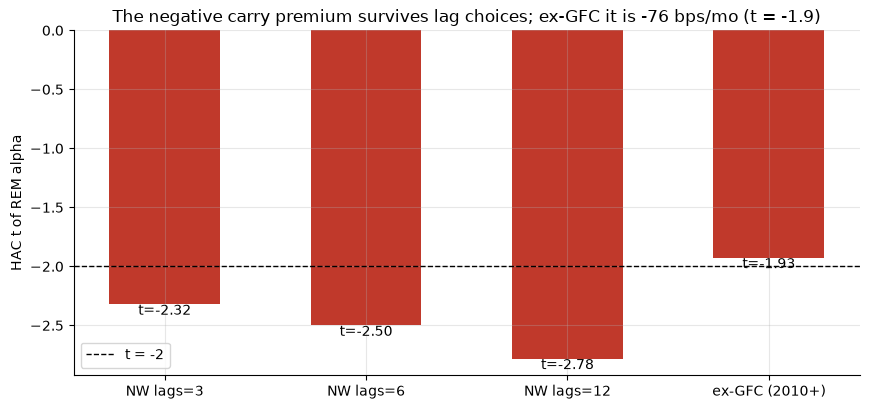

NW lags=3       : alpha -87.62 bps/mo  t = -2.32
NW lags=6       : alpha -87.62 bps/mo  t = -2.50
NW lags=12      : alpha -87.62 bps/mo  t = -2.78
ex-GFC (2010+)  : alpha -76.48 bps/mo  t = -1.93


In [4]:
if HAVE_REAL:
    rows = []
    for lags in (3, 6, 12):
        cp = st.carry_premium(MTR, 'REM', lags=lags)
        rows.append((f'NW lags={lags}', cp['alpha_bps_mo'], cp['t_alpha']))
    cp = st.carry_premium(MTR.loc['2010-01-01':], 'REM')
    rows.append(('ex-GFC (2010+)', cp['alpha_bps_mo'], cp['t_alpha']))
else:
    rows = [(f'NW lags={l}', a, t) for l, a, t in R['robust_lags']]
    rows.append(('ex-GFC (2010+)', R['exgfc']['alpha_bps'], R['exgfc']['t']))
fig, ax = plt.subplots(figsize=(8.8, 4.2))
ax.bar([r[0] for r in rows], [r[2] for r in rows], color=RED, width=.55)
ax.axhline(-2, ls='--', c='k', lw=1, label='t = -2')
for i, r in enumerate(rows): ax.annotate(f't={r[2]:.2f}', (i, r[2]), ha='center', va='top')
ax.set_ylabel('HAC t of REM alpha'); ax.legend()
ax.set_title('The negative carry premium survives lag choices; ex-GFC it is -76 bps/mo (t = -1.9)')
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:<16}: alpha {r[1]:+.2f} bps/mo  t = {r[2]:+.2f}')

> 💡 In plain words: lags 3/6/12 give t = -2.32 / -2.50 / -2.78. Dropping the GFC entirely still leaves α = -76.5 bps/mo (t = -1.93, marginal on the shorter tape) with the dividend intact (+10.3%/yr, t = 17) and the price still eroding (-5.8%/yr). The erosion is chronic, not one bad crisis.

### 4d · Crisis autopsies — the carry's tail

Peak-to-trough total-return drawdowns inside four fixed, documented windows. A genuine bond substitute should look like IEF's column. It looks like leverage.

                     REM   NLY  AGNC   SPY   IEF
crisis                                          
GFC 2007-09        -74.7 -40.9 -31.0 -55.2  -6.2
Taper tantrum 2013 -24.8 -34.6 -36.9  -5.6  -9.1
COVID 2020         -68.5 -60.1 -51.8 -33.7  -4.7
Rate shock 2022    -40.3 -47.8 -48.2 -24.5 -17.4


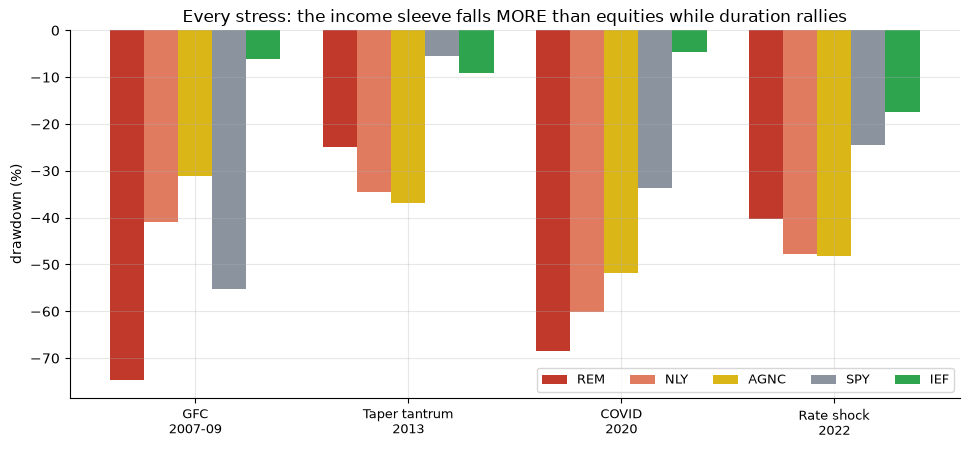

In [5]:
cols = ['REM', 'NLY', 'AGNC', 'SPY', 'IEF']
if HAVE_REAL:
    ct = st.crisis_table(TR, cols)
else:
    ct = pd.DataFrame([c[1:] for c in R['crises']], columns=cols,
                      index=[c[0] for c in R['crises']])
print(ct.round(1).to_string())
fig, ax = plt.subplots(figsize=(9.8, 4.6))
x = np.arange(len(ct)); wdt = .16
shades = [RED, '#e07b5f', AMBER, GREY, GREEN]
for k, (c, col) in enumerate(zip(cols, shades)):
    ax.bar(x + (k - 2) * wdt, ct[c].values, wdt, color=col, label=c)
ax.set_xticks(x); ax.set_xticklabels([i.replace(' 2', '\n2') for i in ct.index], fontsize=9)
ax.set_ylabel('drawdown (%)'); ax.legend(fontsize=9, ncol=5)
ax.set_title('Every stress: the income sleeve falls MORE than equities while duration rallies')
plt.tight_layout(); plt.show()

> 💡 In plain words: in 2008 and 2020 the mREIT complex fell **more than the stock market** while the Treasuries it supposedly monetises went **up** — repo funding vanished and the books were forced sellers (Gorton-Metrick run-on-repo; the 2020 margin spiral). 2013 is the negative-convexity signature: −25 to −37% on a rates *tantrum* that cost SPY 5.6%. The carry is short liquidity and short volatility — it pays until the one month you needed it not to. *(AGNC's GFC cell starts at its 2008-05 listing.)*

### 4e · Faithful-engine control — we know the truth here

Deterministic three-factor world with planted `carry` and `alpha` knobs (seed 611). The null must stay silent; planted values must be recovered.

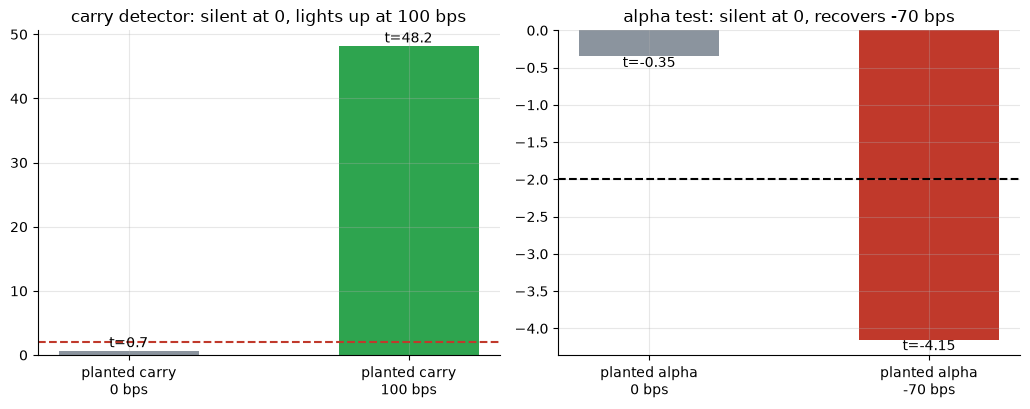

planted carry=  +0.0 alpha=  +0.0 bps/mo -> div +1.49 (t +0.71) | alpha -6.45 (t -0.35)
planted carry=+100.0 alpha= -70.0 bps/mo -> div +101.49 (t +48.21) | alpha -76.45 (t -4.15)


In [6]:
res = []
for carry, alpha in [(0.0, 0.0), (0.010, -0.0070)]:
    ttr, tpx = data.synthetic_world(carry=carry, alpha=alpha, seed=611)
    smtr, smpx = st.aligned_monthly(ttr, tpx, ['MREIT', 'IEF', 'SPY', 'BIL'])
    sd = st.decompose(smtr, smpx, 'MREIT')
    scp = st.carry_premium(smtr, 'MREIT')
    res.append((carry * 1e4, alpha * 1e4, sd['div_bps_mo'], sd['div_hac_t'],
                scp['alpha_bps_mo'], scp['t_alpha']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = [f'planted carry\n{r[0]:.0f} bps' for r in res]
a1.bar(labels, [r[3] for r in res], color=[GREY, GREEN], width=.5)
a1.axhline(2, ls='--', c=RED); a1.set_title('carry detector: silent at 0, lights up at 100 bps')
for i, r in enumerate(res): a1.annotate(f't={r[3]:.1f}', (i, r[3]), ha='center', va='bottom')
labels2 = [f'planted alpha\n{r[1]:.0f} bps' for r in res]
a2.bar(labels2, [r[5] for r in res], color=[GREY, RED], width=.5)
a2.axhline(-2, ls='--', c='k'); a2.set_title('alpha test: silent at 0, recovers -70 bps')
for i, r in enumerate(res): a2.annotate(f't={r[5]:.2f}', (i, r[5]), ha='center',
                                        va='top' if r[5] < 0 else 'bottom')
plt.tight_layout(); plt.show()
for r in res:
    print(f'planted carry={r[0]:+6.1f} alpha={r[1]:+6.1f} bps/mo -> '
          f'div {r[2]:+.2f} (t {r[3]:+.2f}) | alpha {r[4]:+.2f} (t {r[5]:+.2f})')

> 💡 In plain words: under the (0, 0) null the detectors read t = +0.71 and -0.35 — no manufactured significance; the planted +100 bps carry and −70 bps alpha are recovered at t = 48.2 and -4.15, betas 2.64/0.56 vs planted 2.50/0.55. *(A machinery proof only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `REAL`** — the leveraged-MBS carry exists and is huge: REM's dividend component is **+84.69 bps/mo (+10.65%/yr) at HAC t = +18.09** (NLY +13.09%/yr t = 23.0; AGNC +15.59%/yr t = 17.8), and the erosion financing it clears the bar too (α t = -2.50, robust across lags). The headline leg is an index fund — not survivor-biased.
- **Tradability `MIRAGE`** — 19.1 years of harvest left TR CAGR at **-1.13%/yr** (excess over bills t = +0.18: cash, statistically) at 24% vol and a -67% drawdown, losing **-10.02%/yr (t = -2.50)** to a passive levered IEF+SPY mix. Costs are irrelevant (~0.5 bps/yr); the wrapper is the problem.
- **Free lunch? `BUSTED`** — the coupon is financed by the price leg (**-10.96%/yr**; $100 → $10.9 price-only) and carries β_SPY = 1.05 plus a repo margin call. Spending the dividend is spending principal.

## 6 · Going further

- **The packaged-carry family.** [341 — MLP-Pipelines](../../341-mlp-pipelines/README.md) (energy beta under a toll-road label) and [342 — BDC-Yield](../../342-bdc-yield/README.md) (levered private credit under a senior-loan label) are the named siblings — same Real × Mirage pathology, three different assets. The mortgage flavour is the purest carry trade of the three: levered repo NIM, short liquidity, short convexity (Koijen et al. 2018; Gorton-Metrick 2012; Hanson 2014).
- **What would change the verdict.** A post-2022 regime with wide MBS spreads and a steep curve could make H₂ pass on a fresh window; the engine re-runs on any slice — watch the NW alpha vs the levered-IEF benchmark, never the yield.
- **Book equity vs market price.** Our NAV erosion is measured on market prices; book-value-per-share erosion (from filings) is the natural cross-check and gives the same sign — the payout has exceeded the economic earn for most of the sample.

*The reproducible core is offline and deterministic; numbers frozen in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*